## Carga de datos

In [3]:
# Fuente de los datos:
# https://resultados2023.comunidad.madrid/es/

import pandas as pd
import matplotlib.pyplot as plt

URL = 'http://fpaniaguapython.github.io/datos/DatEscrut_Def_Auto_2023_Madrid_Municipios.csv'

try:
    # El archivo utiliza comas (,) como separador en lugar de punto y coma (;)
    df = pd.read_csv(URL, encoding='latin-1', sep=',', thousands='.', decimal=',')
    print("Cargado con éxito usando encoding 'latin-1' y separador de coma")
    display(df.head())
except Exception as e:
    print(f"Error al cargar: {e}")

Cargado con éxito usando encoding 'latin-1' y separador de coma


,Codcir,Codmun,Municipio,Unnamed: 3,Censo,Certif. Alta,Censo Total,Votos Totales,Votos Blancos,Votos Nulos,...,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE
0,28,1.0,La Acebeda,NaN,64,0,64,54,0,1,...,0,0,0,6,0,0,0,1,6,0
1,28,2.0,Ajalvir,NaN,3359,0,3359,2287,33,28,...,1,0,2,395,27,17,8,260,46,2
2,28,3.0,Alameda del Valle,NaN,194,0,194,168,1,3,...,0,0,0,27,3,2,1,18,7,1
3,28,4.0,El Álamo,NaN,7072,6,7078,4732,36,58,...,2,1,6,531,23,25,2,492,164,6
4,28,5.0,Alcalá de Henares,NaN,138572,1,138573,94847,1032,981,...,26,88,115,14951,1553,761,86,7659,4082,120


## Selección de columnas

In [11]:
datos = pd.concat([df['Municipio'], df['Censo Total'], df.iloc[:,13:]], axis=1)
datos

,Municipio,Censo Total,PP,PUM+J,PSOE,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE
0,La Acebeda,64,31,0,9,0,0,0,6,0,0,0,1,6,0
1,Ajalvir,3359,1187,1,280,1,0,2,395,27,17,8,260,46,2
2,Alameda del Valle,194,74,0,31,0,0,0,27,3,2,1,18,7,1
3,El Álamo,7078,2345,7,1034,2,1,6,531,23,25,2,492,164,6
4,Alcalá de Henares,138573,41335,150,21908,26,88,115,14951,1553,761,86,7659,4082,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,Lozoyuela-Navas-Sieteiglesias,994,323,1,134,1,1,2,103,5,6,4,43,62,3
177,Puentes Viejas,565,202,1,50,0,0,1,92,4,3,0,42,34,4
178,Tres Cantos,37963,14204,70,4623,5,14,27,5501,792,164,16,1730,1308,38
179,Residentes ausentes-Madrid,372447,12018,204,4234,26,53,94,4385,528,289,47,2453,2073,168


## Creación de nueva columna con los % de votos sobre un partido

In [14]:
partido = input('Introduce el partido')
partido = partido.upper()

datos['%'+partido] = round((datos[partido]/datos['Censo Total'])*100)
datos

Introduce el partidoPP


,Municipio,Censo Total,PP,PUM+J,PSOE,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE,%PP
0,La Acebeda,64,31,0,9,0,0,0,6,0,0,0,1,6,0,48.0
1,Ajalvir,3359,1187,1,280,1,0,2,395,27,17,8,260,46,2,35.0
2,Alameda del Valle,194,74,0,31,0,0,0,27,3,2,1,18,7,1,38.0
3,El Álamo,7078,2345,7,1034,2,1,6,531,23,25,2,492,164,6,33.0
4,Alcalá de Henares,138573,41335,150,21908,26,88,115,14951,1553,761,86,7659,4082,120,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,Lozoyuela-Navas-Sieteiglesias,994,323,1,134,1,1,2,103,5,6,4,43,62,3,32.0
177,Puentes Viejas,565,202,1,50,0,0,1,92,4,3,0,42,34,4,36.0
178,Tres Cantos,37963,14204,70,4623,5,14,27,5501,792,164,16,1730,1308,38,37.0
179,Residentes ausentes-Madrid,372447,12018,204,4234,26,53,94,4385,528,289,47,2453,2073,168,3.0


## Asignamos el nombre del municipio (convertido a mayúculas) como índice y eliminamos la columna correspondiente

In [15]:
datos.set_index(datos['Municipio'].str.upper(), inplace=True) # Asignar como índice la columna Municipio
datos.drop(columns=['Municipio'], inplace=True) # Eliminando la columna Municipio
display(datos)

,Censo Total,PP,PUM+J,PSOE,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE,%PP
Municipio,,,,,,,,,,,,,,,
LA ACEBEDA,64,31,0,9,0,0,0,6,0,0,0,1,6,0,48.0
AJALVIR,3359,1187,1,280,1,0,2,395,27,17,8,260,46,2,35.0
ALAMEDA DEL VALLE,194,74,0,31,0,0,0,27,3,2,1,18,7,1,38.0
EL ÁLAMO,7078,2345,7,1034,2,1,6,531,23,25,2,492,164,6,33.0
ALCALÁ DE HENARES,138573,41335,150,21908,26,88,115,14951,1553,761,86,7659,4082,120,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LOZOYUELA-NAVAS-SIETEIGLESIAS,994,323,1,134,1,1,2,103,5,6,4,43,62,3,32.0
PUENTES VIEJAS,565,202,1,50,0,0,1,92,4,3,0,42,34,4,36.0
TRES CANTOS,37963,14204,70,4623,5,14,27,5501,792,164,16,1730,1308,38,37.0


## Eliminar la última fila

In [16]:
datos = datos.iloc[:-1]
datos.tail()

,Censo Total,PP,PUM+J,PSOE,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE,%PP
Municipio,,,,,,,,,,,,,,,
ZARZALEJO,1260,350,1,148,0,1,2,213,4,5,1,53,92,1,28.0
LOZOYUELA-NAVAS-SIETEIGLESIAS,994,323,1,134,1,1,2,103,5,6,4,43,62,3,32.0
PUENTES VIEJAS,565,202,1,50,0,0,1,92,4,3,0,42,34,4,36.0
TRES CANTOS,37963,14204,70,4623,5,14,27,5501,792,164,16,1730,1308,38,37.0
RESIDENTES AUSENTES-MADRID,372447,12018,204,4234,26,53,94,4385,528,289,47,2453,2073,168,3.0


## Diagrama de barras del municipio seleccionado

Municipio:parla


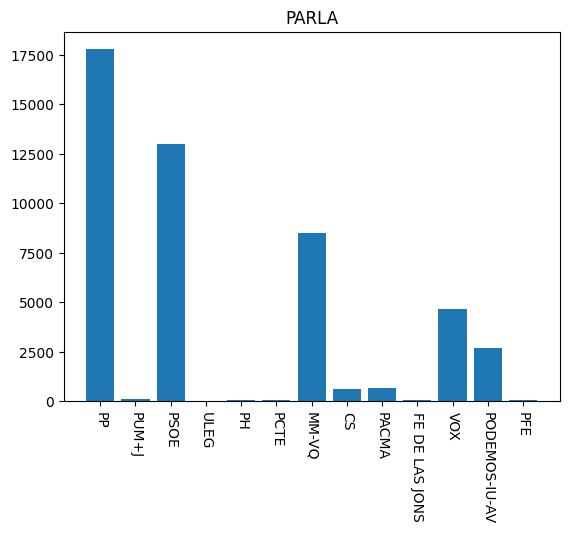

In [21]:
municipio = input('Municipio:')
municipio = municipio.upper()
# Excluimos las columnas primera y última
plt.bar(x=datos.columns[1:-1], height=datos.loc[municipio][1:-1])
plt.xticks(rotation=-90)
plt.title(municipio)
plt.show()

## Diagrama de tartas del municipio seleccionado

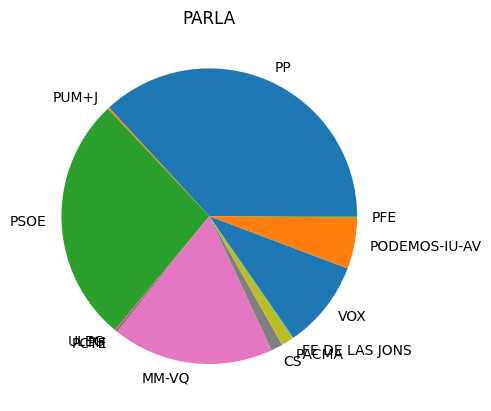

In [22]:
# Excluimos las columnas primera y última
plt.pie(x=datos.loc[municipio][1:-1], labels=datos.columns[1:-1])
plt.title(municipio)
plt.show()

## Diagrama de barras de % de votos de un partido político en los distintos municipios

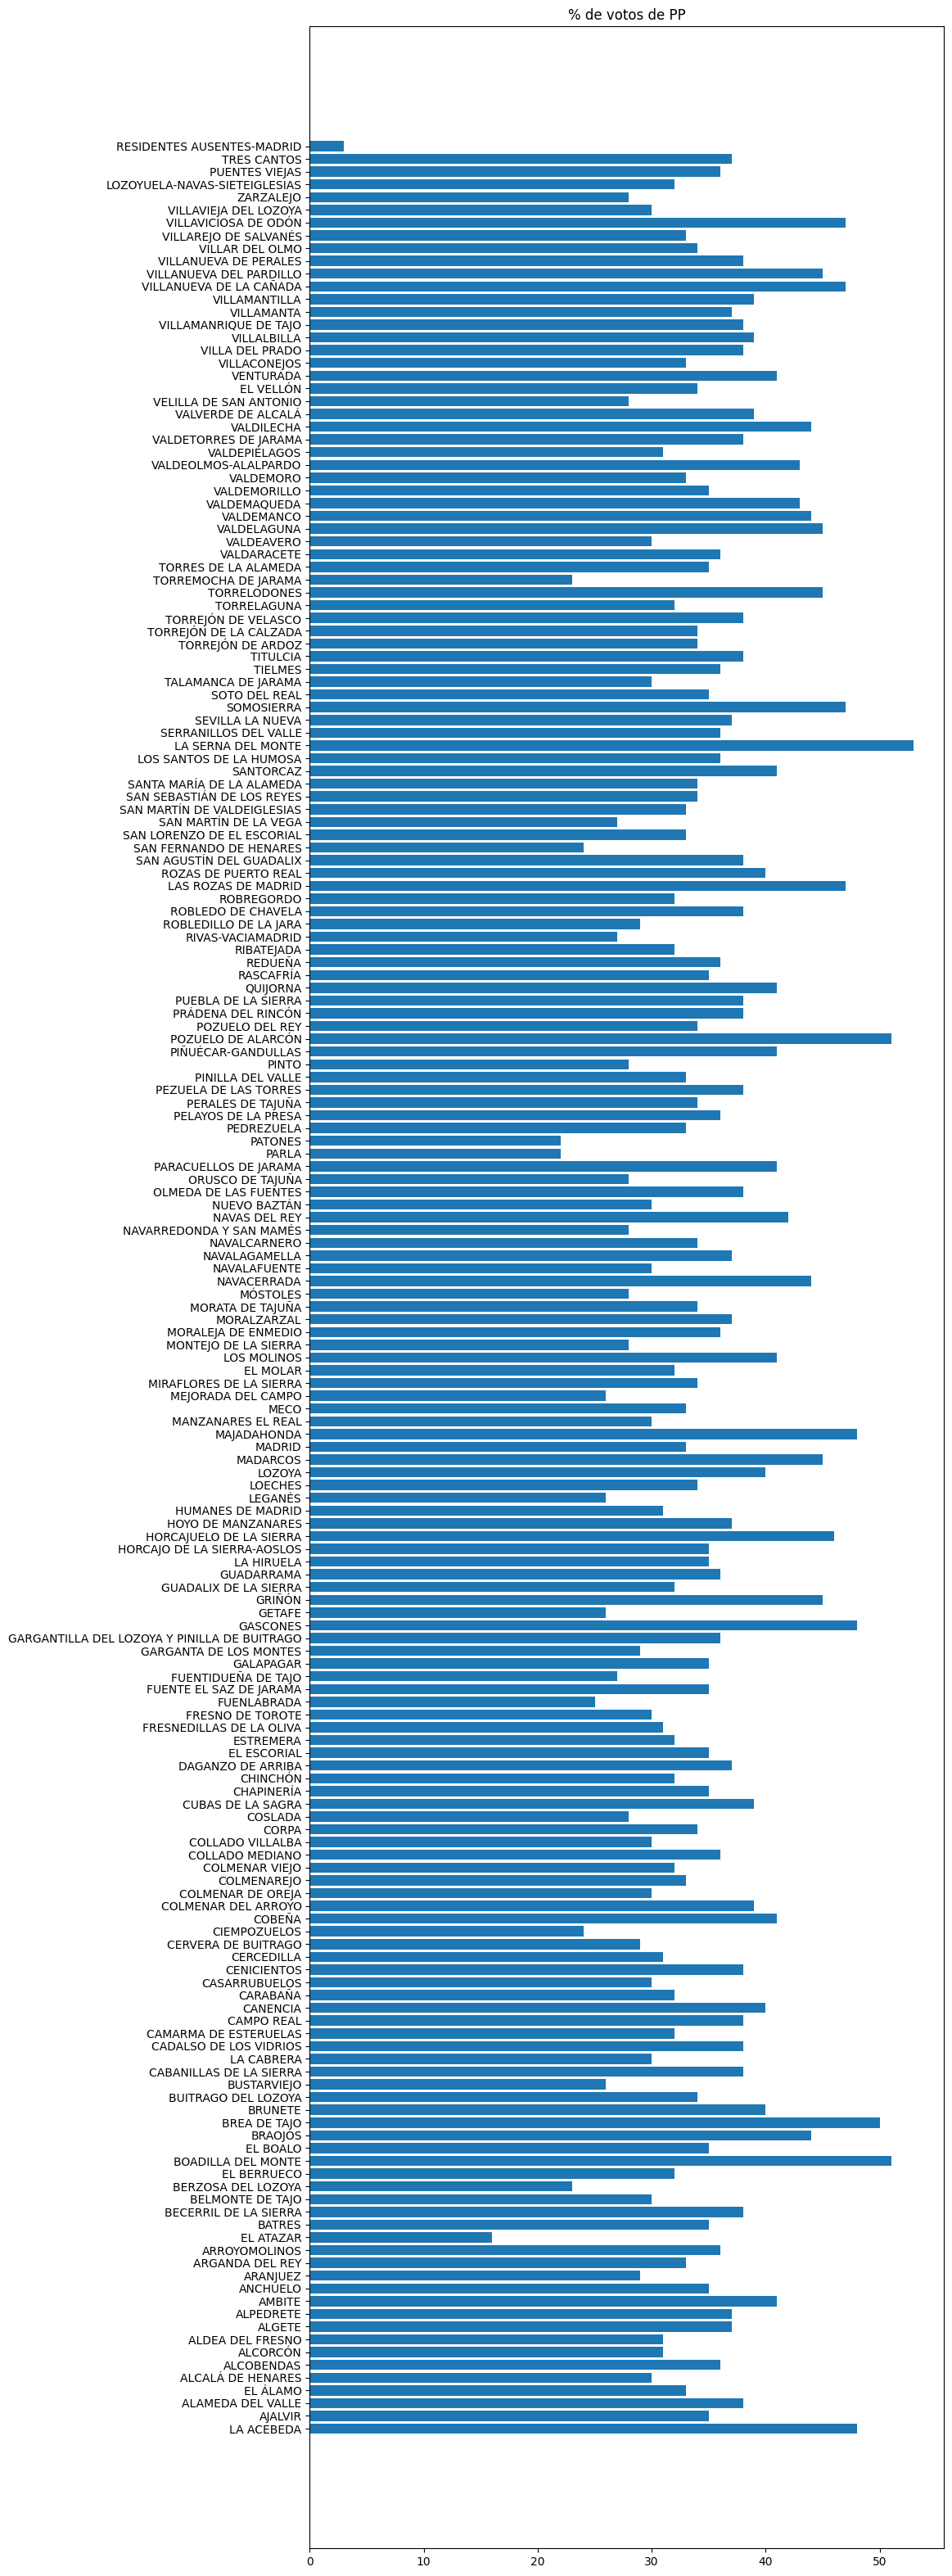

In [27]:
plt.figure(figsize=(10, 40))
plt.barh(y=datos.index, width=datos['%'+partido])
plt.title('% de votos de '+partido)
plt.show()